# DSA MeerKLASS-type Survey: TOD Simulation and Map-Making

This notebook demonstrates a MeerKLASS-style constant-elevation scanning strategy applied to the DSA site.
Two scans (setting and rising) are combined to build sky coverage at Dec ≈ 48°-58°, using north-facing
azimuth sweeps at **el = 55°** (~10° declination strip — closer to a typical IM survey footprint, with
deeper integration per beam than el = 45°). The limTOD package handles beam-convolved TOD generation and
high-pass + Wiener filter map-making.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import numpy as np
from limTOD import TODSim, example_scan, GDSM_sky_model, HPW_mapmaking
from dsa_vis import plot_patch, plot_map_compare
import matplotlib.pyplot as plt
import healpy as hp

In [2]:
# DSA beam wrapper: read zenith beam from FITS and cache per nside
_beam_cache = {}
def dsa_beam_func(*, freq, nside):
    if nside not in _beam_cache:
        beam_128 = hp.read_map('beam_map_zenith.fits')
        if nside != 128:
            _beam_cache[nside] = hp.ud_grade(beam_128, nside)
        else:
            _beam_cache[nside] = beam_128.copy()
    beam = _beam_cache[nside].copy()
    beam /= np.sum(beam)
    return beam

# TOD simulator (forward model) — match the beam's native resolution
sky_Nside = 64
beam_Nside = 128  # nside=128 avoids lmax truncation ripples in rotate_alm

# Map-maker (inverse problem) — pixel scale ~ beam scale.
# FWHM ≈ 4.5°  vs  pixel size: nside=16 → 3.66°, nside=32 → 1.83°.
# nside=16 is comparable to the beam itself: each pixel is essentially
# "one beam", so the inverse problem becomes nearly diagonal and very
# well-conditioned. beam_Nside_map=32 keeps beam-rotation accuracy.
sky_Nside_map = 16
beam_Nside_map = 32

tod_sim = TODSim(
    ant_latitude_deg=39.553969,
    ant_longitude_deg=-114.423973,
    ant_height_m=1746.51,
    beam_func=dsa_beam_func,
    sky_func=GDSM_sky_model,
    beam_nside=beam_Nside,
    sky_nside=sky_Nside,
)

truncate_frac_thres = 1e-3  # larger truncation to avoid alm ringing at beam edges
freq_list = [1000]  # MHz

In [3]:
try:
    data = np.load("simulated_TODs_meerklass.npz", allow_pickle=True)
    freq_list = data["freq_list"].tolist()
    TOD_group = data["TOD_group"]
    LST_deg_list_group = data["LST_deg_list_group"]
    azimuth_deg_list_group = data["azimuth_deg_list_group"]
    elevation_deg_list_group = data["elevation_deg_list_group"]
    print("Loaded existing simulated TODs")
except (FileNotFoundError, KeyError):
    # el = 55° from DSA (lat = 39.55°) gives Dec ≈ 53° at the scan midpoint
    # and ~10° Dec coverage across the ±60°…±42° azimuth sweep — closer
    # to a typical MeerKLASS-style strip and well-matched to the SaS grid.
    el_scan = 55.0

    # Setting scan
    time_setting, az_setting = example_scan(az_s=-60.3, az_e=-42.3, dt=2.0, n_repeats=13)
    start_setting = "2024-04-15 08:25:05"  # tuned so RA-mean = 180°

    # Rising scan
    time_rising, az_rising = example_scan(az_s=42.3, az_e=60.3, dt=2.0, n_repeats=13)
    start_rising = "2024-04-15 02:03:50"   # tuned so RA-mean = 180°

    TOD_group = []
    LST_deg_list_group = []
    azimuth_deg_list_group = []
    elevation_deg_list_group = []

    print("Generating simulated TODs...")

    # Setting scan
    tod_array, _, _, LST_deg_list = tod_sim.generate_TOD(
        freq_list=freq_list,
        time_list=time_setting,
        azimuth_deg_list=az_setting,
        elevation_deg=el_scan,
        start_time_utc=start_setting,
        return_LSTs=True,
        normalize_beam=False,
        truncate_frac_thres=truncate_frac_thres,
    )
    TOD_group.append(tod_array[0])
    LST_deg_list_group.append(LST_deg_list)
    azimuth_deg_list_group.append(az_setting)
    elevation_deg_list_group.append(el_scan * np.ones_like(tod_array[0]))

    # Rising scan
    tod_array, _, _, LST_deg_list = tod_sim.generate_TOD(
        freq_list=freq_list,
        time_list=time_rising,
        azimuth_deg_list=az_rising,
        elevation_deg=el_scan,
        start_time_utc=start_rising,
        return_LSTs=True,
        normalize_beam=False,
        truncate_frac_thres=truncate_frac_thres,
    )
    TOD_group.append(tod_array[0])
    LST_deg_list_group.append(LST_deg_list)
    azimuth_deg_list_group.append(az_rising)
    elevation_deg_list_group.append(el_scan * np.ones_like(tod_array[0]))

    np.savez("simulated_TODs_meerklass.npz",
        TOD_group=TOD_group,
        LST_deg_list_group=LST_deg_list_group,
        azimuth_deg_list_group=azimuth_deg_list_group,
        elevation_deg_list_group=elevation_deg_list_group,
        freq_list=freq_list,
    )
    print("Done! Saved to simulated_TODs_meerklass.npz")

Generating simulated TODs...
No white noise variance is specified!! Using default value of 2.5e-6 (Dimensionless fractional noise)
Generating gain noise with parameters: f0=1.335e-05, fc=0.001099, alpha=2.
Note that these 1/f noise are uncorrelated in frequencies.


  0%|          | 0/2860 [00:00<?, ?it/s]

  0%|          | 1/2860 [00:00<21:00,  2.27it/s]

  0%|          | 2/2860 [00:00<20:59,  2.27it/s]

  0%|          | 3/2860 [00:01<20:48,  2.29it/s]

...

100%|█████████▉| 2858/2860 [21:05<00:00,  4.38it/s]

100%|█████████▉| 2859/2860 [21:05<00:00,  4.38it/s]

100%|██████████| 2860/2860 [21:05<00:00,  4.39it/s]

100%|██████████| 2860/2860 [21:05<00:00,  2.26it/s]

Done! Saved to simulated_TODs_meerklass.npz


In [4]:
# Build HPW mapmaker (expensive — caches the fitted operator via pickle).
# Depends only on beam + scan geometry + nside_target, not on map-making
# parameters (cutoff_freq, prior), so we can iterate on those without rebuilding.
import pickle

# Cache key embeds the nside choice so different runs don't collide.
OPS_CACHE = f"mapmaker_ops_meerklass_ns{sky_Nside_map}.pkl"

try:
    with open(OPS_CACHE, "rb") as f:
        HPW_mapmaker = pickle.load(f)
    print(f"Loaded cached HPW_mapmaker operator from {OPS_CACHE}")
except (FileNotFoundError, EOFError):
    # Build beam at mapmaker resolution; alm derived internally.
    beam_map = dsa_beam_func(freq=freq_list[0], nside=beam_Nside_map)
    lat_deg = tod_sim.ant_latitude_deg

    HPW_mapmaker = HPW_mapmaking(
        beam_map=beam_map,
        LST_deg_list_group=LST_deg_list_group,
        lat_deg=lat_deg,
        azimuth_deg_list_group=azimuth_deg_list_group,
        elevation_deg_list_group=elevation_deg_list_group,
        threshold=0.05,
        nside_target=sky_Nside_map,
        beam_truncate_frac_thres=truncate_frac_thres,
    )
    with open(OPS_CACHE, "wb") as f:
        pickle.dump(HPW_mapmaker, f)
    print(f"Built HPW_mapmaker and cached to {OPS_CACHE}")

pixel_indices = HPW_mapmaker.pixel_indices
print(f"Pixel selection: {len(pixel_indices)} pixels at nside={sky_Nside_map}")

Loaded cached HPW_mapmaker operator from mapmaker_ops_meerklass_ns16.pkl
Pixel selection: 34 pixels at nside=16


In [5]:
# Map-making: no high-pass filter + mild GDSM prior
# - cutoff_freq = 1e-5 Hz with filter_order=1  => butter bandpass ~= identity
#   (period ~28 h; our TOD spans ~3 h, so nothing is filtered in practice)
# - Tsky_prior_mean = GDSM at the recovered pixels (anchors the absolute level)
# - Tsky_prior_inv_cov_diag = 1/sigma_prior^2  with sigma_prior=50 K  (mild)
sky_truth = GDSM_sky_model(freq=freq_list[0], nside=sky_Nside_map)[pixel_indices]

prior_sigma_K = 50.0
prior_inv_cov = np.ones_like(sky_truth) / prior_sigma_K**2

cutoff_freq_group = [1e-5] * len(TOD_group)

sky_map_est, sky_map_uncertainty = HPW_mapmaker(
    TOD_group=np.array(TOD_group),
    dtime=2.0,
    cutoff_freq_group=np.array(cutoff_freq_group),
    gain_group=None,
    known_injection_group=None,
    Tsky_prior_mean=sky_truth,
    Tsky_prior_inv_cov_diag=prior_inv_cov,
    regularization=1e-12,
    return_full_cov=False,
    filter_order=1,
)

print(f"sky_map_est:  min={sky_map_est.min():.3f} K, max={sky_map_est.max():.3f} K, "
      f"mean={sky_map_est.mean():.3f} K")
print(f"sky_truth:    min={sky_truth.min():.3f} K, max={sky_truth.max():.3f} K, "
      f"mean={sky_truth.mean():.3f} K")
print(f"Residual rms: {np.std(sky_map_est - sky_truth):.4f} K")

sky_map_est:  min=-0.167 K, max=0.297 K, mean=-0.019 K
sky_truth:    min=4.564 K, max=4.950 K, mean=4.680 K
Residual rms: 0.0663 K


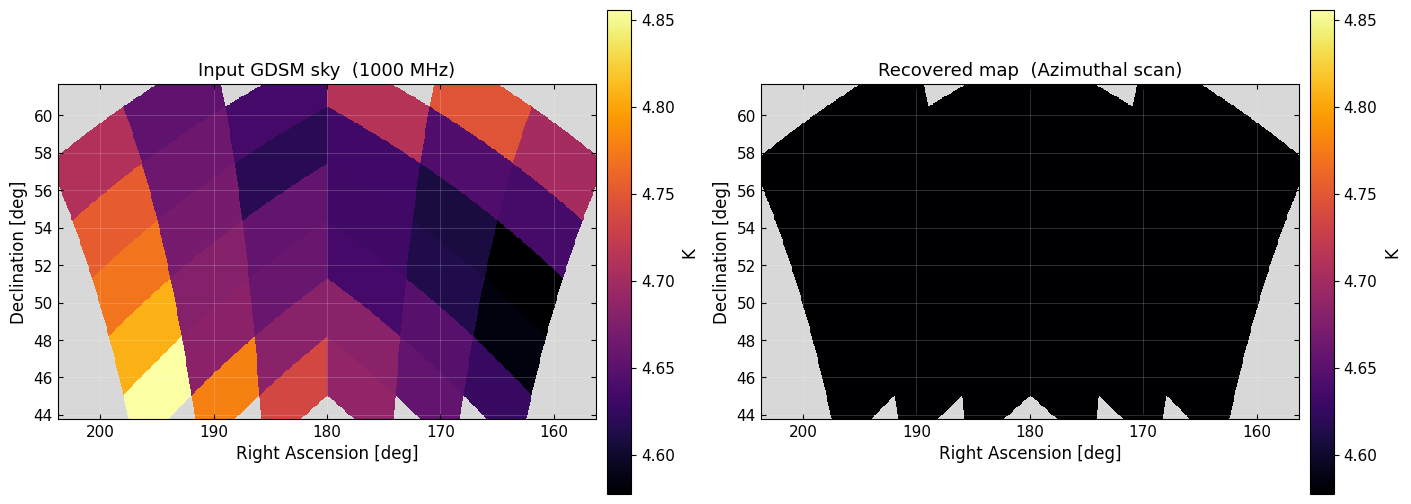

In [6]:
# Side-by-side comparison: input GDSM vs. recovered map
# (sky_truth computed at sky_Nside_map in the previous cell)

fig = plot_map_compare(
    sky_est=sky_map_est,
    sky_truth=sky_truth,
    nside=sky_Nside_map,
    pixel_indices=pixel_indices,
    freq_mhz=freq_list[0],
    strategy_name="Azimuthal scan",
    savepath="figures/map_meerklass.png",
)
plt.show()